In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# S&P 500 data download karo
data = yf.download('SPY', start='2018-01-01', end='2024-12-31')['Close']
data = pd.DataFrame(data)
data.columns = ['Price']

# Daily returns aur rolling volatility
data['Returns'] = data['Price'].pct_change()
data['Volatility'] = data['Returns'].rolling(window=20).std() * np.sqrt(252)
data['MA50'] = data['Price'].rolling(window=50).mean()
data['MA200'] = data['Price'].rolling(window=200).mean()
data.dropna(inplace=True)

print(data.tail())
print(f"\nShape: {data.shape}")

[*********************100%***********************]  1 of 1 completed

                 Price   Returns  Volatility        MA50       MA200
Date                                                                
2024-12-23  586.186646  0.005988    0.134339  581.308159  540.324412
2024-12-24  592.702087  0.011115    0.139520  581.681543  540.799990
2024-12-26  592.741638  0.000067    0.138412  582.144918  541.249001
2024-12-27  586.502075 -0.010527    0.143250  582.433989  541.670757
2024-12-30  579.809204 -0.011412    0.146551  582.588223  542.064012

Shape: (1561, 5)


In [2]:
# Market Regime Detection
def detect_regime(row):
    if row['MA50'] > row['MA200'] and row['Volatility'] < 0.20:
        return 'Bull'
    elif row['MA50'] < row['MA200'] or row['Volatility'] > 0.30:
        return 'Bear'
    else:
        return 'Neutral'

data['Regime'] = data.apply(detect_regime, axis=1)

# Trading signals based on regime
data['Signal'] = 0
data.loc[data['Regime'] == 'Bull', 'Signal'] = 1      # Long in Bull
data.loc[data['Regime'] == 'Bear', 'Signal'] = -1     # Short in Bear

# Strategy returns
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Returns']
data['Cumulative_Strategy'] = (1 + data['Strategy_Returns']).cumprod()
data['Cumulative_BuyHold'] = (1 + data['Returns']).cumprod()

# Sharpe Ratio
sharpe = (data['Strategy_Returns'].mean() / data['Strategy_Returns'].std()) * np.sqrt(252)

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"\nRegime Distribution:")
print(data['Regime'].value_counts())

Sharpe Ratio: 0.38

Regime Distribution:
Regime
Bull       1054
Bear        373
Neutral     134
Name: count, dtype: int64


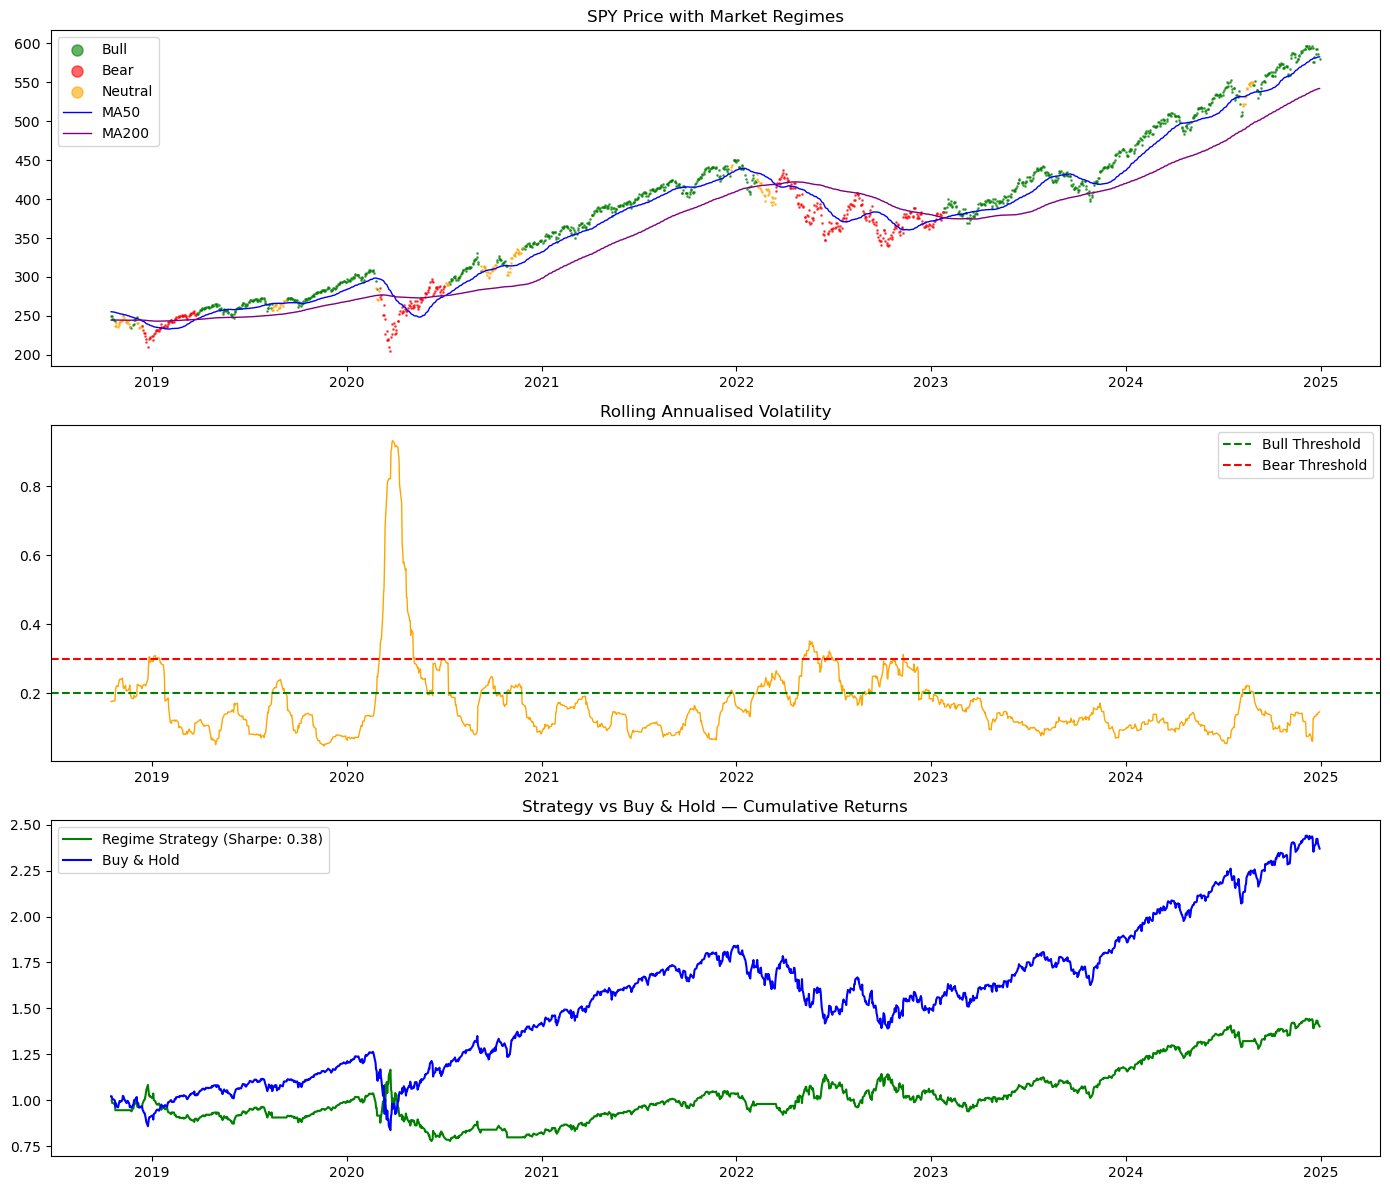


✅ Market Regime Detection Project Complete!


In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Price + Regimes
colors = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'orange'}
for regime, color in colors.items():
    mask = data['Regime'] == regime
    ax1.scatter(data.index[mask], data['Price'][mask], 
                c=color, s=1, label=regime, alpha=0.6)
ax1.plot(data['MA50'], color='blue', linewidth=1, label='MA50')
ax1.plot(data['MA200'], color='purple', linewidth=1, label='MA200')
ax1.set_title('SPY Price with Market Regimes')
ax1.legend(markerscale=8)

# Plot 2: Volatility
ax2.plot(data['Volatility'], color='orange', linewidth=1)
ax2.axhline(0.20, color='green', linestyle='--', label='Bull Threshold')
ax2.axhline(0.30, color='red', linestyle='--', label='Bear Threshold')
ax2.set_title('Rolling Annualised Volatility')
ax2.legend()

# Plot 3: Strategy vs Buy & Hold
ax3.plot(data['Cumulative_Strategy'], color='green', 
         linewidth=1.5, label=f'Regime Strategy (Sharpe: {sharpe:.2f})')
ax3.plot(data['Cumulative_BuyHold'], color='blue', 
         linewidth=1.5, label='Buy & Hold')
ax3.set_title('Strategy vs Buy & Hold — Cumulative Returns')
ax3.legend()

plt.tight_layout()
plt.savefig('market_regime_detection.png', dpi=150)
plt.show()

print("\n✅ Market Regime Detection Project Complete!")